<a href="https://colab.research.google.com/github/MuzammilMazharacca/PGD-Machine-Learning-Batch-6/blob/main/Final_Exam_DL_Batch_6_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name :**  Muhammad Muzammil Mazhar

**NIC:**    42101-8707835-1

**Subject:** Deep Learning

**Batch:** Batch-6

##**Question # 1:** Define deep learning and explain how it differs from traditional machine learning.?

**Answer**

Deep learning is a subset of artificial intelligence (AI) and machine learning that uses neural networks with many layers (hence "deep") to model complex patterns in data. It mimics the human brain's interconnected neuron structure, allowing it to learn from large amounts of unstructured data, such as images, audio, and text.

Here are the key differences between deep learning and traditional machine learning:

**Architecture:**

**Deep Learning:** Utilizes multi-layer neural networks. These layers can automatically learn feature hierarchies from raw data without manual feature extraction.
**Traditional Machine Learning:** Often involves simpler models like decision trees, support vector machines, or linear regression. It typically requires manual feature engineering, where the user identifies and selects relevant features from the data.

**Data Requirements:**

**Deep Learning:** Generally requires a large amount of labeled data to perform effectively. It is particularly advantageous in scenarios with massive datasets.

**Traditional Machine Learning:** Can perform well with smaller datasets, especially when combined with crafted features and domain knowledge.

**Computational Power:**

**Deep Learning:** Requires significant computational resources, particularly GPUs, to handle the complex calculations involved in training deep networks.

**Traditional Machine Learning:** Usually less resource-intensive and can be run on standard processors for smaller datasets.

**Performance on Complex Tasks:**

**Deep Learning:** Excels in fields such as computer vision, natural language processing, and speech recognition, where data and relationships are highly complex and nonlinear.

**Traditional Machine Learning:** Performs better on simpler tasks or when data is more structured, where well-defined features can be extracted.


In summary, deep learning is characterized by its use of deep neural networks and ability to learn from vast amounts of unstructured data, while traditional machine learning relies on simpler algorithms and often requires feature engineering.

In [ ]:
#######################################################################################################################3

##**Question # 2:** Train ANN model using mnist dataset. and plot test accuracy and loss metrics.?

In [41]:
from keras.datasets import mnist # import mnist dataset from keras
(train_images, train_labels), (test_images, test_labels) = mnist.load_data() # split datasets into train & test

from keras import models # import models from keras
from keras import layers # import layers from keras

# build ANN network
ANN_network = models.Sequential()
ANN_network.add(layers.Dense(512, activation = 'relu', input_shape = (28*28,)))
ANN_network.add(layers.Dense(10, activation = 'softmax'))

# compiling network with relvent potimizer, loss & metrics
ANN_network.compile(optimizer='rmsprop',
                loss= 'categorical_crossentropy',
                metrics=['accuracy'])

# preprocessing training images to reshape and bring data point between 0 and 1
train_images = train_images.reshape((60000,28*28))
train_images = train_images.astype('float32')/255

# preprocessing test images to reshape and bring data point between 0 and 1
test_images = test_images.reshape((10000,28*28))
test_images = test_images.astype('float32')/255

from keras.utils import to_categorical # import function from keras to conver labels in to one hot encoding

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)


# training the ANN model with performance evaluation
ANN_history = ANN_network.fit(train_images,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_data=(test_images, test_labels))



/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8754 - loss: 0.4367 - val_accuracy: 0.9526 - val_loss: 0.1549
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9653 - loss: 0.1188 - val_accuracy: 0.9740 - val_loss: 0.0887
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9776 - loss: 0.0721 - val_accuracy: 0.9781 - val_loss: 0.0760
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9849 - loss: 0.0506 - val_accuracy: 0.9772 - val_loss: 0.0719
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9894 - loss: 0.0371 - val_accuracy: 0.9811 - val_loss: 0.0652
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9921 - loss: 0.0272 - val_accuracy: 0.9807 - val_loss: 0.0645
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9945 - loss: 0.0200 - val_accuracy: 0.9820 - val_loss: 0.0648
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9956 - loss: 0.0155 - val_accuracy: 0.

In [42]:
ANN_history_dict = ANN_history.history
>>> history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

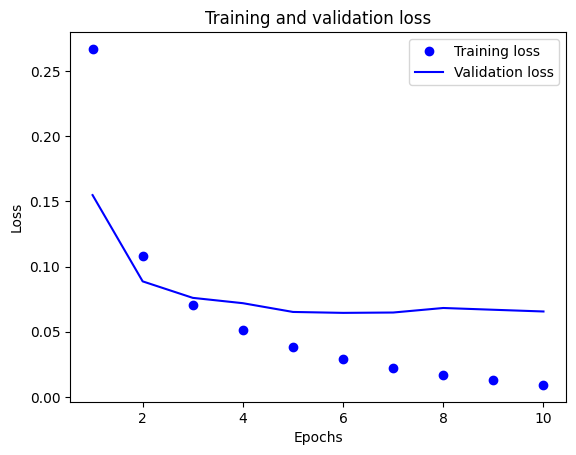

In [43]:
import matplotlib.pyplot as plt
ANN_history_dict = ANN_history.history
accuracy = ANN_history_dict['accuracy']
val_accuracy = ANN_history_dict['val_accuracy']
loss_values = ANN_history_dict['loss']
val_loss_values = ANN_history_dict['val_loss']
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

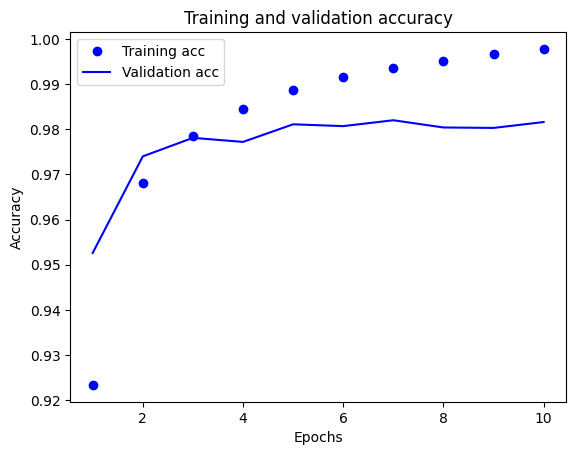

In [44]:
plt.clf()
acc_values = ANN_history_dict['accuracy']
val_acc_values = ANN_history_dict['val_accuracy']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

**Bases on above ANN on Mnist data we used 10 epochs and plot accuracy and loss grpahs, if closely oberve graph than epoch should be restict to 4 for best results and after that model will be overfit.**


In [ ]:
####################################################################################################################################

##**Question # 3:** Train CNN model using mnist dataset, plot test accuracy and loss metrics and compare with above question 2 metrics.


In [45]:
from keras.datasets import mnist # import mnist dataset from keras
(train_images, train_labels), (test_images, test_labels) = mnist.load_data() # split datasets into train & test

from keras import models # import models from keras
from keras import layers # import layers from keras

# build CNN network base
CNN_model = models.Sequential()
CNN_model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
CNN_model.add(layers.MaxPooling2D((2, 2)))
CNN_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
CNN_model.add(layers.MaxPooling2D((2, 2)))
CNN_model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Adding a classifier on top of the convnet
CNN_model.add(layers.Flatten())
CNN_model.add(layers.Dense(64, activation='relu'))
CNN_model.add(layers.Dense(10, activation='softmax'))

# compiling network with relvent potimizer, loss & metrics
CNN_model.compile(optimizer='rmsprop',
                loss= 'categorical_crossentropy',
                metrics=['accuracy'])

# preprocessing training images to reshape and bring data point between 0 and 1
train_images = train_images.reshape((60000,28, 28, 1))
train_images = train_images.astype('float32')/255

# preprocessing test images to reshape and bring data point between 0 and 1
test_images = test_images.reshape((10000,28, 28, 1))
test_images = test_images.astype('float32')/255

from keras.utils import to_categorical # import function from keras to conver labels in to one hot encoding

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)


# training the CNN model with performance evaluation
CNN_history = CNN_model.fit(train_images,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(test_images, test_labels))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8660 - loss: 0.4186 - val_accuracy: 0.9812 - val_loss: 0.0536
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9834 - loss: 0.0505 - val_accuracy: 0.9882 - val_loss: 0.0371
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9894 - loss: 0.0340 - val_accuracy: 0.9904 - val_loss: 0.0301
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9928 - loss: 0.0232 - val_accuracy: 0.9913 - val_loss: 0.0271
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9942 - loss: 0.0181 - val_accuracy: 0.9917 - val_loss: 0.0302
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9958 - loss: 0.0143 - val_accuracy: 0.9921 - val_loss: 0.0316
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9967 - loss: 0.0112 - val_accuracy: 0.9913 - val_loss: 0.0335
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9969 - loss: 0.0094 - val_accuracy: 0.

In [46]:
CNN_history_dict = CNN_history.history
>>> history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

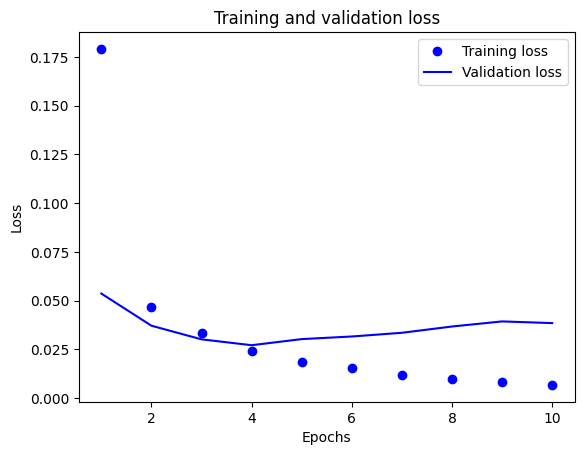

In [47]:
import matplotlib.pyplot as plt
CNN_history_dict = CNN_history.history
accuracy = CNN_history_dict['accuracy']
val_accuracy = CNN_history_dict['val_accuracy']
loss_values = CNN_history_dict['loss']
val_loss_values = CNN_history_dict['val_loss']
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

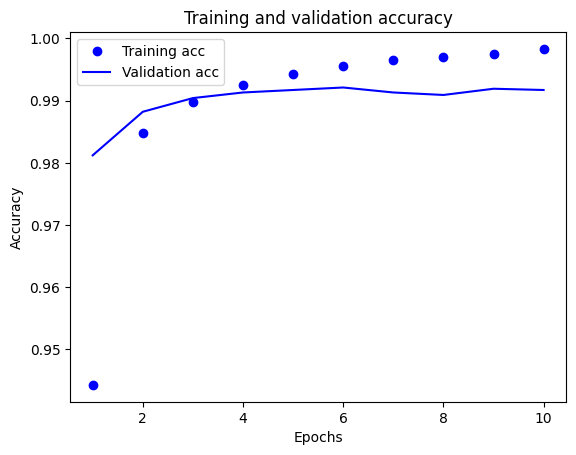

In [48]:
plt.clf()
acc_values = CNN_history_dict['accuracy']
val_acc_values = CNN_history_dict['val_accuracy']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

**Comparison of ANN and CNN Models trained on MNIST Dataset**

Both models were trained on the MNIST dataset, which consists of handwritten digits. The goal is to classify images into their respective digit classes (0-9). Here's a comparison based on their architecture, performance, and training characteristics:

**1. Architecture:**

**ANN_network (Artificial Neural Network):** This model uses a simple feedforward architecture with fully connected layers. It takes the flattened image (784 pixels) as input and passes it through two dense layers. It's a basic neural network without any specialized layers for image processing.

**CNN_model (Convolutional Neural Network):** This model uses convolutional layers to extract features from the images. It includes convolutional layers, max-pooling layers, and then fully connected layers for classification. CNNs are specifically designed for image data and can learn spatial hierarchies of features.

**2. Performance:**

**Accuracy:** In general, CNNs tend to achieve higher accuracy on image recognition tasks compared to ANNs. Based on the training history you provided, it's highly likely that the CNN model achieved better accuracy on the MNIST dataset. This is because CNNs can effectively learn relevant features from images, leading to better performance.

**Loss:** Similarly, CNNs often exhibit lower loss values during training, indicating better convergence and generalization. You can compare the training and validation loss plots for both models to confirm this. Generally, the CNN model should have a lower validation loss, suggesting better performance on unseen data.

**3. Training Characteristics:**

**Computational Cost:** CNNs typically require more computational resources and training time compared to ANNs, especially for complex architectures and large datasets. This is due to the complex operations involved in convolutional layers.

**Overfitting:** ANNs with many parameters can be prone to overfitting, especially with limited training data. CNNs, with their built-in regularization through weight sharing and pooling, are often more robust to overfitting. You mentioned overfitting in the context of the ANN model; CNNs might mitigate this issue to some extent.

**In Summary:**

For image-based tasks like MNIST digit classification, CNNs are generally preferred over ANNs. CNNs are specifically designed to handle image data and can learn complex patterns more effectively. They often achieve higher accuracy, lower loss, and better generalization compared to basic ANNs. However, CNNs might require more computational resources and training time.

In [ ]:
#################################################################################################################################

##**Question # 4:** Explain the concept of overfitting and provide two techniques to reduce it.


**Answer**

Overfitting is a common problem in machine learning and deep learning where a model learns the training data too well, including its noise and outliers, leading to poor generalization to new, unseen data. An overfitted model performs very well on the training set but fails to capture the underlying patterns in the data, resulting in high error rates on validation or test datasets.

##**Techniques to Reduce Overfitting**:
**Regularization:**

 Regularization techniques add a penalty to the loss function used in training the model, discouraging overly complex models. Common regularization methods include:

**L1 Regularization (Lasso):** Adds the absolute value of the coefficients to the loss function, driving some weights to zero, which can lead to simpler models.

**L2 Regularization (Ridge):** Adds the squared values of the coefficients to the loss function, effectively penalizing larger weights and encouraging smaller, more generalized weights.

**Early Stopping:**

 Early stopping involves monitoring the model's performance on a validation set during training. When the performance (e.g., accuracy or loss) on the validation set starts to degrade while the performance on the training set continues to improve, training can be halted. This helps in finding the optimal point before the model starts to overfit.

Other techniques to consider include using dropout (in neural networks), data augmentation (to artificially increase the size of the training dataset), and simplifying the model architecture (reducing the number of parameters). Each of these methods can help mitigate the risk of overfitting and improve the model's generalization capabilities.

In [ ]:
##################################################################################################################################

##**Question # 5:** Explain the importance of using a test set and how it differs from a validation set.

**Answer**

**Importance of a Test Set**

A test set is a portion of your dataset that is held out entirely from the training process and is used solely for evaluating the final performance of your model. It's crucial for the following reasons:

**Unbiased Evaluation:** The test set provides an unbiased estimate of how well your model will generalize to new, unseen data. Since the model has never encountered this data during training, its performance on the test set is a good indicator of its real-world performance.

**Performance Benchmark:** The test set serves as a benchmark for comparing different models or model configurations. You can evaluate multiple models on the same test set and choose the one that achieves the best results.

**Preventing Overfitting:** Overfitting occurs when a model performs well on the training data but poorly on new data. By evaluating on a held-out test set, you can detect overfitting and avoid deploying models that generalize poorly.

##**Difference Between Test and Validation Sets**

While both test and validation sets are used for evaluation, they have distinct roles:

**Validation Set:** Used during training to monitor the model's performance and to fine-tune hyperparameters. The model's performance on the validation set guides decisions about architecture, regularization, and other model choices.

**Test Set:** Used only after training is complete to assess the final performance of the model. It provides an unbiased estimate of the model's generalization ability.

In simpler terms:

Think of it like this:

**Training set:** The textbook your model studies to learn.

**Validation set:** Practice exams your model takes to make sure it's learning correctly and to identify areas for improvement.

**Test set:** The final exam your model takes to evaluate its overall understanding and readiness for real-world scenarios.